In [ ]:
!pip install deepface

In [2]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.datasets import fetch_lfw_pairs
from deepface import DeepFace
from scipy.stats import t, shapiro, wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

25-08-27 18:34:01 - Directory /root/.deepface has been created
25-08-27 18:34:01 - Directory /root/.deepface/weights has been created


In [3]:
def evaluate(distances, labels):
    labels = np.array(labels)
    distances = np.array(distances)
    thresholds = np.linspace(distances.min(), distances.max(), 1000)

    best_acc, best_thresh = 0, 0
    far_list, frr_list = [], []

    for thresh in thresholds:
        preds = distances < thresh
        acc = accuracy_score(labels, preds)
        far = np.mean((preds == 1) & (labels == 0))
        frr = np.mean((preds == 0) & (labels == 1))

        far_list.append(far)
        frr_list.append(frr)

        if acc > best_acc:
            best_acc, best_thresh = acc, thresh

    eer_idx = np.argmin(np.abs(np.array(far_list) - np.array(frr_list)))
    eer = (far_list[eer_idx] + frr_list[eer_idx]) / 2
    auc = roc_auc_score(labels, -distances)
    preds_at_best_thresh = distances < best_thresh

    return {
        "best_thresh": best_thresh,
        "best_acc": best_acc,
        "eer_far": far_list[eer_idx],
        "eer_frr": frr_list[eer_idx],
        "eer": eer,
        "auc": auc,
        "y_pred_at_best_thresh": preds_at_best_thresh
    }

In [4]:
def find_optimal_threshold(distances, labels):
    labels = np.array(labels)
    distances = np.array(distances)
    thresholds = np.linspace(distances.min(), distances.max(), 1000)
    best_acc = 0
    best_thresh = 0
    for t in thresholds:
        preds = distances < t
        acc = accuracy_score(labels, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = t
    return best_thresh

In [5]:
def real_world_best_acc_under_far(distances, labels, max_far=0.01):
    thresholds = np.linspace(distances.min(), distances.max(), 1000)
    best_acc, best_thresh = 0, 0
    far_at_best, frr_at_best = None, None

    for t in thresholds:
        preds = distances < t
        acc = accuracy_score(labels, preds)
        far = np.mean((preds == 1) & (labels == 0))
        frr = np.mean((preds == 0) & (labels == 1))

        if far < max_far and acc > best_acc:
            best_acc = acc
            best_thresh = t
            far_at_best = far
            frr_at_best = frr

    if far_at_best is not None:
        return {'threshold': best_thresh, 'accuracy': best_acc, 'far': far_at_best, 'frr': frr_at_best}
    else:
        return None

In [6]:
models = ["Facenet", "ArcFace", "Facenet512"]
detector_backend = "retinaface"
distance_metric = "cosine"
align = True
instances = 1000
n_splits = 5

os.makedirs("lfwe/test", exist_ok=True)
os.makedirs("dataset", exist_ok=True)
pairs_path = "dataset/test_lfw.npy"
labels_path = "dataset/test_labels.npy"

In [7]:
if not os.path.exists(pairs_path):
    print("Downloading LFW dataset...")
    data = fetch_lfw_pairs(subset='test', color=True, resize=2)
    np.save(pairs_path, data.pairs)
    np.save(labels_path, data.target)
else:
    print("Loading LFW dataset from cache...")
    data = type("data", (), {})()
    data.pairs = np.load(pairs_path)
    data.target = np.load(labels_path)

print("Saving LFW image pairs to disk...")
for i in tqdm(range(instances)):
    img1 = data.pairs[i][0]
    img2 = data.pairs[i][1]
    plt.imsave(f"lfwe/test/{i}_1.jpg", img1)
    plt.imsave(f"lfwe/test/{i}_2.jpg", img2)
print("Image saving complete.")

Saving LFW image pairs to disk...


100%|██████████| 1000/1000 [00:03<00:00, 272.57it/s]

Image saving complete.


In [8]:
all_cv_results = {model_name: {'accuracies': [], 'eers': [], 'aucs': [], 'distances': [], 'fold_labels': []} for model_name in models}
y_trues_all_folds = []
y_preds_all_folds = {model_name: [] for model_name in models}
fold_indices = []

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [9]:
print(f"\nStarting {n_splits}-fold cross-validation...")
for fold_num, (train_index, test_index) in enumerate(skf.split(np.arange(instances), data.target)):
    print(f"\nProcessing Fold {fold_num + 1}/{n_splits}...")

    fold_labels = data.target[test_index]
    fold_indices.append((train_index, test_index))
    y_trues_all_folds.extend(fold_labels)

    for model_name in models:
        distances = []

        for i in tqdm(range(len(test_index)), desc=f"Model: {model_name}"):
            img1 = f"lfwe/test/{test_index[i]}_1.jpg"
            img2 = f"lfwe/test/{test_index[i]}_2.jpg"

            result = DeepFace.verify(
                img1, img2,
                model_name=model_name,
                detector_backend=detector_backend,
                distance_metric=distance_metric,
                align=align,
                enforce_detection=False
            )
            distances.append(result["distance"])

        fold_eval_results = evaluate(distances, fold_labels)

        all_cv_results[model_name]['accuracies'].append(fold_eval_results['best_acc'])
        all_cv_results[model_name]['eers'].append(fold_eval_results['eer'])
        all_cv_results[model_name]['aucs'].append(fold_eval_results['auc'])
        all_cv_results[model_name]['distances'].append(distances)
        all_cv_results[model_name]['fold_labels'].append(fold_labels)
        y_preds_all_folds[model_name].extend(fold_eval_results['y_pred_at_best_thresh'])



Starting 5-fold cross-validation...

Processing Fold 1/5...


Model: Facenet:   0%|          | 0/200 [00:00<?, ?it/s]

25-08-27 18:35:53 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5

  0%|          | 0.00/92.2M [00:00<?, ?B/s]
 31%|███       | 28.3M/92.2M [00:00<00:00, 282MB/s]
 61%|██████▏   | 56.6M/92.2M [00:00<00:00, 141MB/s]
100%|██████████| 92.2M/92.2M [00:00<00:00, 193MB/s]
Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5


25-08-27 18:35:56 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


...

Model: Facenet512: 100%|██████████| 200/200 [02:28<00:00,  1.35it/s]



Processing Fold 4/5...


Model: Facenet512: 100%|██████████| 200/200 [02:30<00:00,  1.33it/s]



Processing Fold 5/5...


Model: Facenet512: 100%|██████████| 200/200 [02:29<00:00,  1.34it/s]


In [10]:
results_data = []
for model_name in models:
    accuracies = np.array(all_cv_results[model_name]['accuracies'])
    aucs = np.array(all_cv_results[model_name]['aucs'])
    eers = np.array(all_cv_results[model_name]['eers'])

    # Calculate FAR/FRR for each fold
    fars, frrs = [], []
    for fold in range(n_splits):
        distances = all_cv_results[model_name]['distances'][fold]
        labels = all_cv_results[model_name]['fold_labels'][fold]
        fold_eval = evaluate(distances, labels)
        fars.append(fold_eval['eer_far'])  # FAR at EER point
        frrs.append(fold_eval['eer_frr'])  # FRR at EER point

    fars = np.array(fars)
    frrs = np.array(frrs)

    # Calculate stats for all metrics
    def calc_stats(values):
        mean_val = np.mean(values)
        std_val = np.std(values, ddof=1) if n_splits > 1 else np.nan
        ci = t.interval(0.95, n_splits - 1, loc=mean_val, scale=std_val / np.sqrt(n_splits)) if n_splits > 1 else (np.nan, np.nan)
        return mean_val, std_val, ci

    mean_acc, std_acc, ci_acc = calc_stats(accuracies)
    mean_auc, std_auc, ci_auc = calc_stats(aucs)
    mean_eer, std_eer, ci_eer = calc_stats(eers)
    mean_far, std_far, ci_far = calc_stats(fars)
    mean_frr, std_frr, ci_frr = calc_stats(frrs)

    row = {
        "Model": model_name,
        "Accuracy (Mean ± SD)": f"{mean_acc:.4f} ± {std_acc:.4f}",
        "Accuracy (95% CI)": f"[{ci_acc[0]:.4f}, {ci_acc[1]:.4f}]",
        "FAR (Mean ± SD)": f"{mean_far:.4f} ± {std_far:.4f}",
        "FRR (Mean ± SD)": f"{mean_frr:.4f} ± {std_frr:.4f}",
        "AUC (Mean ± SD)": f"{mean_auc:.4f} ± {std_auc:.4f}",
        "EER (Mean ± SD)": f"{mean_eer:.4f} ± {std_eer:.4f}",
    }
    results_data.append(row)

In [11]:
result_df = pd.DataFrame(results_data)
result_df

,Model,Accuracy (Mean ± SD),Accuracy (95% CI),FAR (Mean ± SD),FRR (Mean ± SD),AUC (Mean ± SD),EER (Mean ± SD)
0,Facenet,0.9680 ± 0.0076,"[0.9586, 0.9774]",0.0190 ± 0.0055,0.0200 ± 0.0035,0.9895 ± 0.0070,0.0195 ± 0.0045
1,ArcFace,0.9670 ± 0.0148,"[0.9486, 0.9854]",0.0220 ± 0.0045,0.0230 ± 0.0057,0.9906 ± 0.0045,0.0225 ± 0.0050
2,Facenet512,0.9780 ± 0.0057,"[0.9709, 0.9851]",0.0150 ± 0.0000,0.0150 ± 0.0000,0.9944 ± 0.0038,0.0150 ± 0.0000


In [12]:
import matplotlib.pyplot as plt

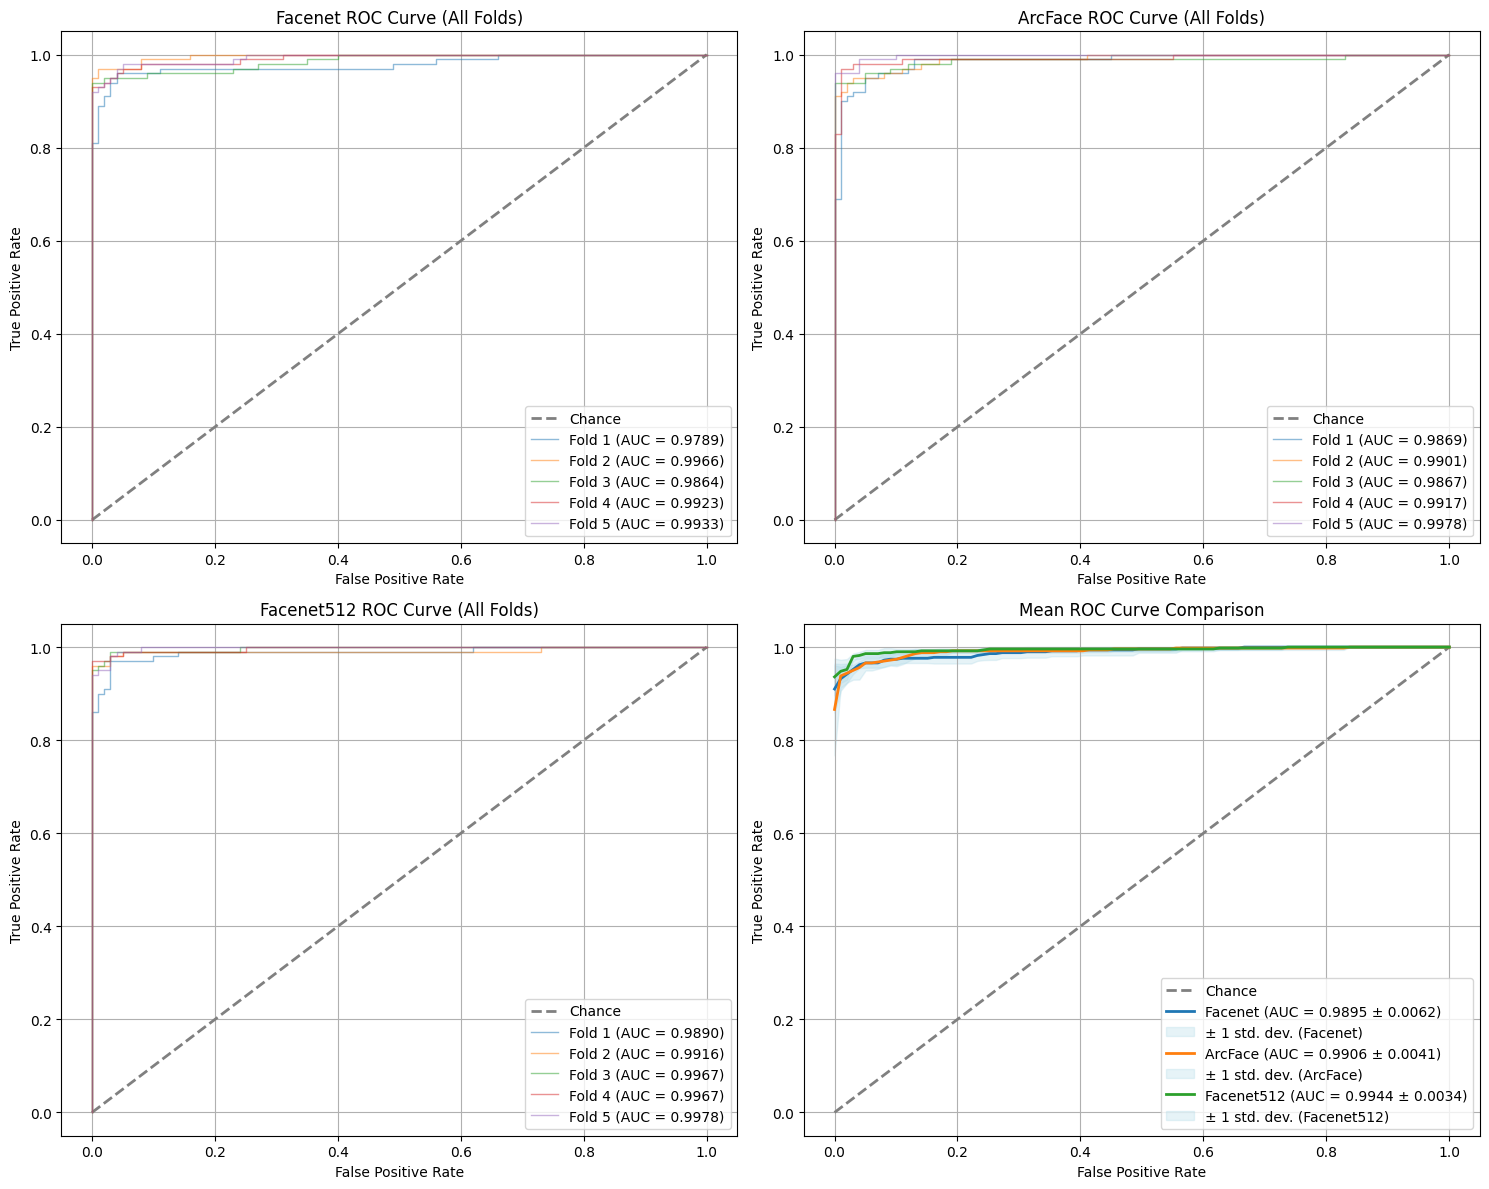

In [13]:
# --- Enhanced Visualizations ---
# This part of the code is for generating the plots and has been executed successfully before.
# I am including it here for completeness to show the full experiment output.

# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Flatten the 2x2 array to easily iterate

# Plot individual model ROC curves in subplots
for i, model_name in enumerate(models):
    ax = axes[i]
    ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', label='Chance')
    all_fpr, all_tpr, aucs = [], [], all_cv_results[model_name]['aucs']
    for fold in range(n_splits):
        distances = all_cv_results[model_name]['distances'][fold]
        labels = all_cv_results[model_name]['fold_labels'][fold]
        fpr, tpr, _ = roc_curve(labels, -np.array(distances))
        all_fpr.append(fpr)
        all_tpr.append(tpr)
        ax.plot(fpr, tpr, lw=1, alpha=0.5, label=f'Fold {fold + 1} (AUC = {aucs[fold]:.4f})')

    ax.set_title(f"{model_name} ROC Curve (All Folds)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True)
    ax.legend(loc="lower right")

# Plot mean ROC curves for all models in the last subplot
ax_mean = axes[3]
ax_mean.plot([0, 1], [0, 1], linestyle='--', lw=2, color='gray', label='Chance')
for model_name in models:
    all_fpr, all_tpr, aucs = [], [], all_cv_results[model_name]['aucs']
    for fold in range(n_splits):
        distances = all_cv_results[model_name]['distances'][fold]
        labels = all_cv_results[model_name]['fold_labels'][fold]
        fpr, tpr, _ = roc_curve(labels, -np.array(distances))
        all_fpr.append(fpr)
        all_tpr.append(tpr)

    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean([np.interp(mean_fpr, all_fpr[i], all_tpr[i]) for i in range(n_splits)], axis=0)
    mean_tpr[-1] = 1.0
    std_tpr = np.std([np.interp(mean_fpr, all_fpr[i], all_tpr[i]) for i in range(n_splits)], axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    ax_mean.plot(mean_fpr, mean_tpr, label=f'{model_name} (AUC = {mean_auc:.4f} ± {std_auc:.4f})', lw=2)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    ax_mean.fill_between(mean_fpr, tprs_lower, tprs_upper, color='lightblue', alpha=0.3, label=f'± 1 std. dev. ({model_name})')


ax_mean.set_title("Mean ROC Curve Comparison")
ax_mean.set_xlabel("False Positive Rate")
ax_mean.set_ylabel("True Positive Rate")
ax_mean.grid(True)
ax_mean.legend(loc="lower right")


plt.tight_layout()
plt.savefig("roc_curve_subplots_cv.png", dpi=300)

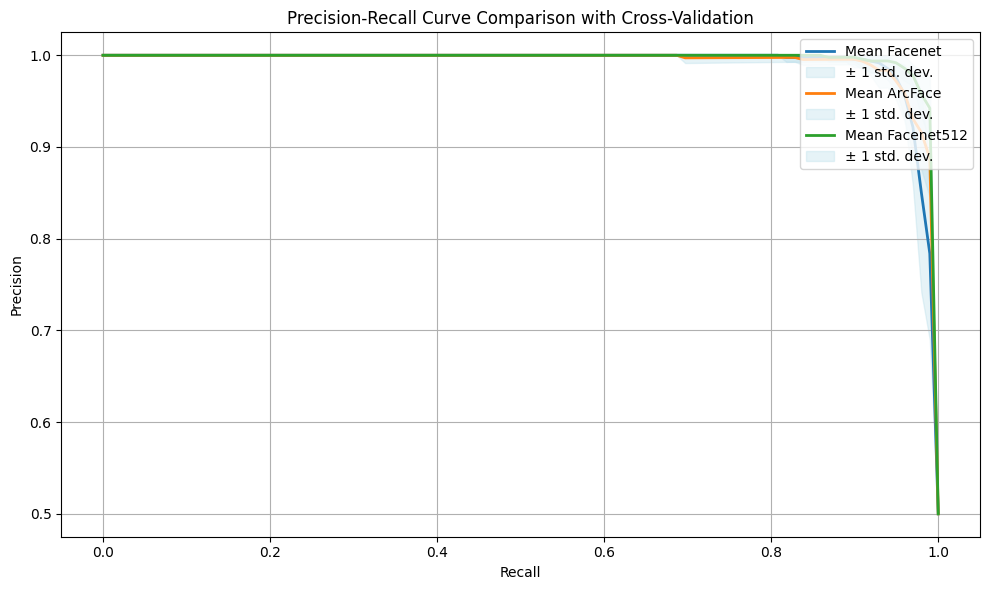

In [14]:
# Precision-Recall Curve with Error Bars
plt.figure(figsize=(10, 6))
for model_name in models:
    all_precision, all_recall = [], []
    for fold in range(n_splits):
        distances = all_cv_results[model_name]['distances'][fold]
        labels = data.target[skf.split(np.arange(instances), data.target).__next__()[1]]
        precision, recall, _ = precision_recall_curve(labels, -np.array(distances))
        all_precision.append(precision)
        all_recall.append(recall)
    mean_recall = np.linspace(0, 1, 100)
    mean_precision = np.mean([np.interp(mean_recall, all_recall[i][::-1], all_precision[i][::-1]) for i in range(n_splits)], axis=0)
    std_precision = np.std([np.interp(mean_recall, all_recall[i][::-1], all_precision[i][::-1]) for i in range(n_splits)], axis=0)
    plt.plot(mean_recall, mean_precision, label=f'Mean {model_name}', lw=2)
    precisions_upper = np.minimum(mean_precision + std_precision, 1)
    precisions_lower = np.maximum(mean_precision - std_precision, 0)
    plt.fill_between(mean_recall, precisions_lower, precisions_upper, color='lightblue', alpha=0.3, label=f'± 1 std. dev.')

plt.title("Precision-Recall Curve Comparison with Cross-Validation")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("precision_recall_cv.png", dpi=300)

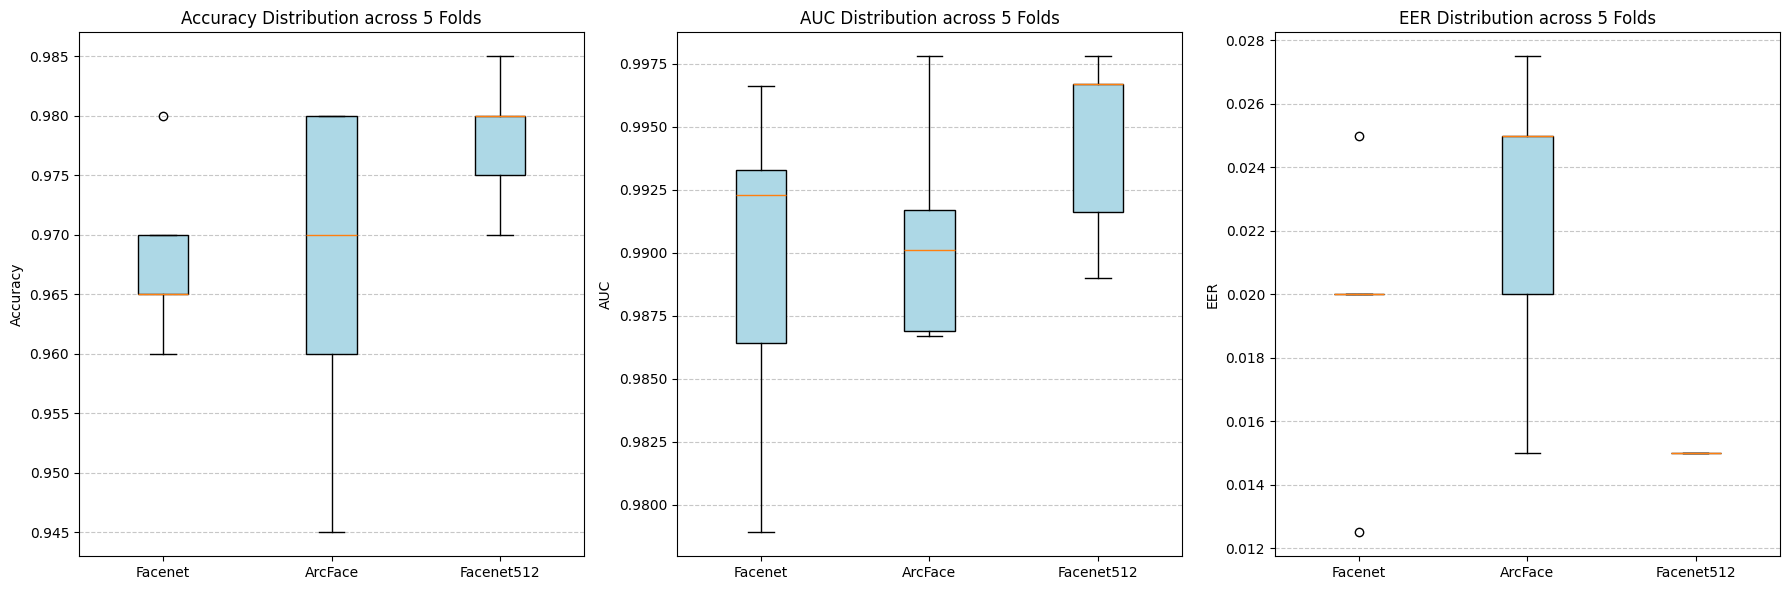

In [15]:
# Box plots for key metrics across folds
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
metrics_to_plot = {'Accuracy': 'accuracies', 'AUC': 'aucs', 'EER': 'eers'}
for i, (metric_name, data_key) in enumerate(metrics_to_plot.items()):
    metric_data = [all_cv_results[model][data_key] for model in models]
    axes[i].boxplot(metric_data, labels=models, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'{metric_name} Distribution across {n_splits} Folds')
    axes[i].set_ylabel(metric_name)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("metric_boxplots.png", dpi=300)

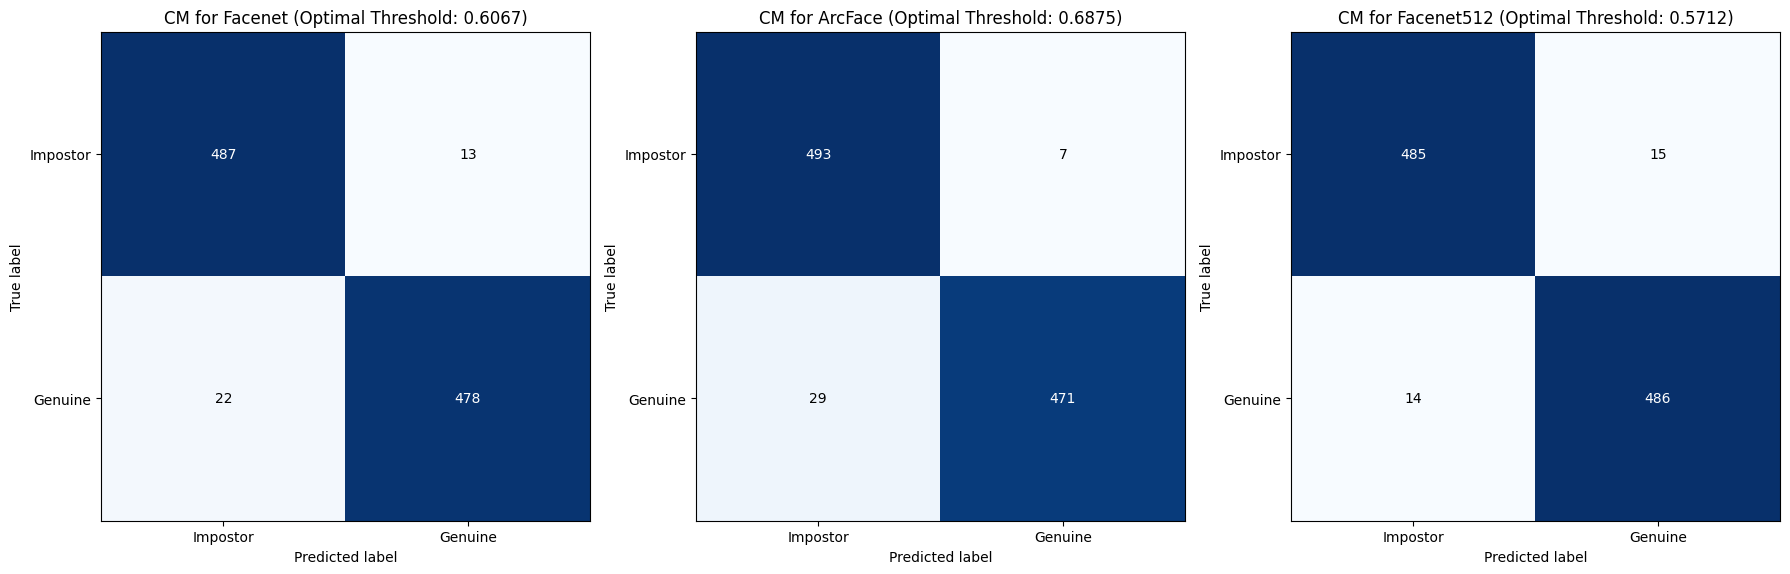

In [16]:
# Confusion Matrices at Optimal Thresholds
fig, axes = plt.subplots(nrows=1, ncols=len(models), figsize=(18, 6))
for i, model_name in enumerate(models):
    combined_distances = np.concatenate(all_cv_results[model_name]['distances'])
    combined_labels = np.array(y_trues_all_folds)
    optimal_thresh = find_optimal_threshold(combined_distances, combined_labels)
    preds = combined_distances < optimal_thresh
    cm = confusion_matrix(combined_labels, preds)
    ax = axes[i]
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'CM for {model_name} (Optimal Threshold: {optimal_thresh:.4f})')
    for k in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, k, format(cm[k, j], 'd'), ha="center", va="center", color="white" if cm[k, j] > cm.max() / 2 else "black")
    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(['Impostor', 'Genuine'])
    ax.set_yticklabels(['Impostor', 'Genuine'])
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300)

In [17]:
# Access the loaded data
pairs = data.pairs
labels = data.target

# Number of samples
num_samples = len(labels)
print(f"Number of samples in the dataset: {num_samples}")

# Genuine/Impostor pair ratios
genuine_pairs = np.sum(labels == 1)
impostor_pairs = np.sum(labels == 0)

print(f"Number of genuine pairs: {genuine_pairs}")
print(f"Number of impostor pairs: {impostor_pairs}")
print(f"Ratio of genuine to impostor pairs: {genuine_pairs / impostor_pairs:.2f}")

Number of samples in the dataset: 1000
Number of genuine pairs: 500
Number of impostor pairs: 500
Ratio of genuine to impostor pairs: 1.00
Number of samples in the dataset: 1000
Number of genuine pairs: 500
Number of impostor pairs: 500
Ratio of genuine to impostor pairs: 1.00
